# Vetting Statistics

This notebook summarizes retrieved vetting fields from MALCA vetted parquet products and plots their distributions.

Numeric fields are shown as histograms, boolean fields as bar charts, categorical fields as top-N bar charts, and free-text identifier columns are treated as completeness metrics rather than forced into fake histograms.


In [12]:
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    pass

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.frameon': True,
})


## Configuration

- Leave `VETTED_FILES` empty to auto-discover `lc_events_vetted*.parquet` under the first run root that actually contains vetted outputs.
- Standard pipeline outputs only include columns produced by `vet_candidates(...)`; optional follow-up light-curve columns may be absent.


In [13]:
def _run_root_has_vetted_files(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    try:
        for run_dir in path.iterdir():
            results_dir = run_dir / 'results'
            if not results_dir.exists():
                continue
            if (results_dir / 'lc_events_vetted.parquet').exists():
                return True
            if any(p.name.startswith('lc_events_vetted_') for p in results_dir.glob('lc_events_vetted_*.parquet')):
                return True
    except OSError:
        return False
    return False


RUN_ROOT_CANDIDATES = [
    Path('output/runs'),
    Path.cwd() / 'output/runs',
    Path('../../output/runs'),
    Path.cwd().parent / 'output/runs',
    Path.cwd().parent.parent / 'output/runs',
]
RUN_ROOT_CANDIDATES = [path.expanduser() for path in RUN_ROOT_CANDIDATES]
RUNS_ROOT = next(
    (path for path in RUN_ROOT_CANDIDATES if _run_root_has_vetted_files(path)),
    next((path for path in RUN_ROOT_CANDIDATES if path.exists()), RUN_ROOT_CANDIDATES[0]),
)
print(f'Using run root: {RUNS_ROOT.resolve()}')
VETTED_FILES = []
RUN_PATTERNS = [
    ('12_12.5', '12-12.5'),
    ('12.5_13', '12.5-13'),
    ('13_13.5', '13-13.5'),
    ('13.5_14', '13.5-14'),
    ('14_14.5', '14-14.5'),
    ('14.5_15', '14.5-15'),
]
TOP_N_CATEGORIES = 12
PERCENTILE_CLIP = (0.01, 0.99)

BASE_COLORS = [
    '#1b9e77', '#d95f02', '#7570b3', '#e7298a',
    '#66a61e', '#e6ab02', '#a6761d', '#666666',
]

KNOWN_VETTING_COLUMNS = [
    'vetting_likely_known',
    'simbad_main_id', 'simbad_otype', 'simbad_nbref', 'simbad_sep_arcsec',
    'gaia_var_flag', 'gaia_var_class', 'gaia_var_score',
    'gaia_eb_period', 'gaia_eb_morph', 'gaia_eb_global_ranking',
    'gaia_epoch_available', 'gaia_epoch_n_obs', 'gaia_epoch_g_range',
    'asassn_var_name', 'asassn_var_type', 'asassn_var_period',
    'ztf_var_type', 'ztf_var_period', 'ztf_var_amp',
    'tns_name', 'tns_type', 'tns_redshift', 'tns_disc_date',
    'alerce_oid', 'alerce_ndet', 'alerce_lc_class', 'alerce_lc_prob',
    'alerce_stamp_class', 'alerce_stamp_prob',
    'xray_det', 'xray_flux', 'xray_sep_arcsec',
    'vsx_class', 'vsx_sep_arcsec',
    'sfr_name', 'sfr_sep_arcmin',
    'cluster_name', 'cluster_dist_pc',
    'banyan_best_assoc', 'banyan_field_prob',
    'yso_class',
    'iphas_ha_excess',
    'pm_cluster_offset_sigma',
    'atlas_has_phot', 'atlas_n_det_cyan', 'atlas_n_det_orange',
    'atlas_cyan_range', 'atlas_orange_range',
    'neowise_n_epochs', 'neowise_w1_range', 'neowise_w2_range',
]

VETTING_PREFIXES = (
    'vetting_', 'simbad_', 'gaia_', 'asassn_', 'ztf_', 'tns_',
    'alerce_', 'xray_', 'vsx_', 'sfr_', 'cluster_', 'banyan_',
    'yso_', 'iphas_', 'pm_', 'atlas_', 'neowise_',
)

BOOLEAN_COLUMNS = {
    'vetting_likely_known',
    'gaia_var_flag',
    'gaia_epoch_available',
    'xray_det',
    'atlas_has_phot',
    'iphas_ha_excess',
}

CATEGORICAL_COLUMNS = {
    'simbad_otype',
    'gaia_var_class',
    'gaia_eb_morph',
    'asassn_var_type',
    'ztf_var_type',
    'tns_type',
    'alerce_lc_class',
    'alerce_stamp_class',
    'vsx_class',
    'sfr_name',
    'cluster_name',
    'banyan_best_assoc',
    'yso_class',
}

TEXT_COLUMNS = {
    'simbad_main_id',
    'asassn_var_name',
    'tns_name',
    'tns_disc_date',
    'alerce_oid',
}

MODULE_MARKERS = {
    'Likely known': 'vetting_likely_known',
    'SIMBAD': 'simbad_main_id',
    'Gaia variability': 'gaia_var_flag',
    'Gaia EB': 'gaia_eb_period',
    'Gaia epoch photometry': 'gaia_epoch_available',
    'ASAS-SN variables': 'asassn_var_type',
    'ZTF variables': 'ztf_var_type',
    'TNS': 'tns_name',
    'ALeRCE': 'alerce_oid',
    'eROSITA': 'xray_det',
    'ATLAS': 'atlas_has_phot',
    'PM consistency': 'pm_cluster_offset_sigma',
    'NEOWISE': 'neowise_n_epochs',
}

LOG10_COLUMNS = {
    'simbad_nbref',
    'simbad_sep_arcsec',
    'gaia_eb_period',
    'gaia_epoch_n_obs',
    'gaia_epoch_g_range',
    'asassn_var_period',
    'ztf_var_period',
    'ztf_var_amp',
    'alerce_ndet',
    'xray_flux',
    'xray_sep_arcsec',
    'atlas_n_det_cyan',
    'atlas_n_det_orange',
    'atlas_cyan_range',
    'atlas_orange_range',
    'neowise_n_epochs',
    'neowise_w1_range',
    'neowise_w2_range',
}


Using run root: /home/calder/code/malca/output/runs


In [14]:
def infer_mag_bin_label(run_dir: Path) -> str:
    run_params = run_dir / 'run_params.json'
    if run_params.exists():
        try:
            params = json.loads(run_params.read_text())
            mag_bin = params.get('mag_bin')
            if mag_bin:
                return str(mag_bin)
            mag_min = params.get('mag_min')
            mag_max = params.get('mag_max')
            if mag_min is not None and mag_max is not None:
                return f'{float(mag_min):g}-{float(mag_max):g}'
        except Exception:
            pass

    match = re.search(r'(\d+(?:\.\d+)?)_(\d+(?:\.\d+)?)', run_dir.name)
    if match:
        return f'{float(match.group(1)):g}-{float(match.group(2)):g}'
    return run_dir.name


def sort_labels(labels):
    preferred = [label for _, label in RUN_PATTERNS]
    present = {str(label) for label in labels if pd.notna(label)}
    ordered = [label for label in preferred if label in present]

    leftovers = []
    for label in labels:
        if pd.isna(label):
            continue
        label_str = str(label)
        if label_str not in ordered and label_str not in leftovers:
            leftovers.append(label_str)

    def key(label):
        match = re.match(r'^(\d+(?:\.\d+)?)-(\d+(?:\.\d+)?)$', str(label))
        if match:
            return (0, float(match.group(1)), float(match.group(2)), str(label))
        return (1, str(label))

    return ordered + sorted(leftovers, key=key)


def pick_vetted_file(run_dir: Path) -> Path | None:
    results_dir = run_dir / 'results'
    if not results_dir.exists():
        return None

    exact = results_dir / 'lc_events_vetted.parquet'
    if exact.exists():
        return exact

    matches = sorted(
        [p for p in results_dir.glob('lc_events_vetted_*.parquet') if 'CHECKPOINT' not in p.name],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    return matches[0] if matches else None


def discover_vetted_files() -> pd.DataFrame:
    rows = []
    if VETTED_FILES:
        paths = [Path(p) for p in VETTED_FILES]
        for path in paths:
            if not path.exists():
                continue
            run_dir = path.parent.parent
            rows.append({
                'run_name': run_dir.name,
                'mag_bin': infer_mag_bin_label(run_dir),
                'candidate_file': path,
            })
    else:
        run_dirs = sorted([p for p in RUNS_ROOT.iterdir() if p.is_dir()])
        for token, label in RUN_PATTERNS:
            matches = []
            for run_dir in run_dirs:
                if token not in run_dir.name:
                    continue
                candidate_file = pick_vetted_file(run_dir)
                if candidate_file is not None:
                    matches.append((run_dir, candidate_file))
            if not matches:
                print(f'Warning: no vetted parquet found for {label} under {RUNS_ROOT}')
                continue
            run_dir, candidate_file = max(matches, key=lambda item: item[1].stat().st_mtime)
            rows.append({
                'run_name': run_dir.name,
                'mag_bin': label,
                'candidate_file': candidate_file,
            })

    if not rows:
        raise FileNotFoundError(f'No vetted parquet files found under {RUNS_ROOT}')
    return pd.DataFrame(rows)


def load_vetting_frame(file_manifest: pd.DataFrame) -> pd.DataFrame:
    frames = []
    for row in file_manifest.itertuples(index=False):
        df = pd.read_parquet(row.candidate_file)
        df = df.copy()
        df['run_name'] = row.run_name
        df['mag_bin'] = row.mag_bin
        df['candidate_file'] = str(row.candidate_file)
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f'No readable vetted parquet files found in {RUNS_ROOT}')
    return pd.concat(frames, ignore_index=True)


def present_count(series: pd.Series) -> int:
    if pd.api.types.is_bool_dtype(series):
        return int(series.fillna(False).sum())
    if pd.api.types.is_numeric_dtype(series):
        s = pd.to_numeric(series, errors='coerce')
        if set(pd.unique(s.dropna())) <= {0.0, 1.0}:
            return int(s.fillna(0).sum())
        return int(s.notna().sum())
    clean = series.dropna().astype(str).str.strip()
    clean = clean[clean != '']
    normalized = clean.str.lower()
    bool_tokens = {'true', 'false', '1', '0', 'yes', 'no', 'y', 'n'}
    if not normalized.empty and set(normalized.unique()) <= bool_tokens:
        truthy = {'true', '1', 'yes', 'y'}
        return int(normalized.isin(truthy).sum())
    return int(clean.count())


def numeric_series(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce')
    return s[np.isfinite(s)]


def classify_column(col: str, series: pd.Series) -> str:
    if col in BOOLEAN_COLUMNS:
        return 'boolean'
    if col in CATEGORICAL_COLUMNS:
        return 'categorical'
    if col in TEXT_COLUMNS:
        return 'text'
    if pd.api.types.is_numeric_dtype(series):
        return 'numeric'
    clean = series.fillna('').astype(str).str.strip()
    clean = clean[clean != '']
    if clean.empty:
        return 'text'
    if clean.nunique() <= TOP_N_CATEGORIES:
        return 'categorical'
    return 'text'


def numeric_group(col: str) -> str:
    if col.startswith('simbad_') or col.endswith('_sep_arcsec') or col.endswith('_sep_arcmin'):
        return 'Match quality and separation'
    if col.startswith('gaia_'):
        return 'Gaia retrieved stats'
    if col.startswith('asassn_') or col.startswith('ztf_'):
        return 'ASAS-SN and ZTF'
    if col.startswith('tns_') or col.startswith('alerce_'):
        return 'TNS and ALeRCE'
    if col.startswith('xray_') or col.startswith('pm_') or col.startswith('banyan_'):
        return 'X-ray and environment'
    if col.startswith('atlas_') or col.startswith('neowise_'):
        return 'ATLAS and NEOWISE'
    return 'Other numeric vetting'


NUMERIC_GROUP_ORDER = [
    'Match quality and separation',
    'Gaia retrieved stats',
    'ASAS-SN and ZTF',
    'TNS and ALeRCE',
    'X-ray and environment',
    'ATLAS and NEOWISE',
    'Other numeric vetting',
]


def transform_numeric(col: str, series: pd.Series) -> tuple[pd.Series, str, str]:
    s = numeric_series(series)
    xlabel = col
    transform = 'linear'
    if col in LOG10_COLUMNS:
        s = s[s > 0]
        if not s.empty:
            s = np.log10(s)
            xlabel = f'log10({col})'
            transform = 'log10'
    return s, xlabel, transform


def clip_series(series: pd.Series) -> pd.Series:
    if series.empty:
        return series
    lo = series.quantile(PERCENTILE_CLIP[0])
    hi = series.quantile(PERCENTILE_CLIP[1])
    clipped = series[(series >= lo) & (series <= hi)]
    return clipped if not clipped.empty else series


def palette_for(labels: list[str]) -> dict[str, str]:
    ordered = sort_labels(labels)
    return {label: BASE_COLORS[i % len(BASE_COLORS)] for i, label in enumerate(ordered)}


def build_inventory(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in cols:
        series = df[col]
        numeric = numeric_series(series)
        _, _, transform = transform_numeric(col, series)
        rows.append({
            'column': col,
            'column_type': classify_column(col, series),
            'group': numeric_group(col) if pd.api.types.is_numeric_dtype(series) else '',
            'non_null': int(series.notna().sum()),
            'completeness': float(series.notna().mean()),
            'n_unique_non_null': int(series.dropna().nunique()),
            'transform': transform,
            'min': float(numeric.min()) if not numeric.empty else np.nan,
            'max': float(numeric.max()) if not numeric.empty else np.nan,
        })
    inventory = pd.DataFrame(
        rows,
        columns=[
            'column',
            'column_type',
            'group',
            'non_null',
            'completeness',
            'n_unique_non_null',
            'transform',
            'min',
            'max',
        ],
    )
    if inventory.empty:
        return inventory
    return inventory.sort_values(['column_type', 'group', 'column']).reset_index(drop=True)


def _blank_axis(ax, message: str) -> None:
    ax.axis('off')
    ax.text(0.5, 0.5, message, ha='center', va='center', transform=ax.transAxes)


def _subplot_grid(n_items: int, max_cols: int = 3, base_height: float = 3.0):
    n_items = max(int(n_items), 1)
    n_cols = min(max_cols, n_items)
    n_rows = int(np.ceil(n_items / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, base_height * n_rows),
        squeeze=False,
    )
    return fig, axes.ravel()


def _ordered_mag_bins(df: pd.DataFrame) -> list[str]:
    if 'mag_bin' not in df.columns:
        return ['all']
    return sort_labels(df['mag_bin'].dropna().astype(str).unique())


def _series_for_mag_bin(df: pd.DataFrame, mag_bin: str, col: str) -> pd.Series:
    if mag_bin == 'all' and 'mag_bin' not in df.columns:
        return df[col]
    return df.loc[df['mag_bin'].astype(str) == str(mag_bin), col]


def plot_boolean_overview(df: pd.DataFrame, cols: list[str]) -> None:
    if not cols:
        print('No boolean vetting columns found.')
        return

    mag_bins = _ordered_mag_bins(df)
    fraction_summary = pd.DataFrame(index=cols, columns=mag_bins, dtype=float)
    count_rows = []
    for col in cols:
        for mag_bin in mag_bins:
            series = _series_for_mag_bin(df, mag_bin, col)
            n_rows = len(series)
            hits = present_count(series)
            fraction_summary.loc[col, mag_bin] = hits / n_rows if n_rows else np.nan
            count_rows.append({
                'column': col,
                'mag_bin': mag_bin,
                'hit_rows': hits,
                'n_rows': n_rows,
                'hit_fraction': hits / n_rows if n_rows else np.nan,
            })

    display(pd.DataFrame(count_rows))
    values = fraction_summary.to_numpy(dtype=float)
    vmax = float(np.nanmax(values)) if np.isfinite(values).any() else 1.0
    fig, ax = plt.subplots(
        figsize=(max(7, 1.2 * len(mag_bins)), max(3, 0.45 * len(cols))),
    )
    image = ax.imshow(fraction_summary.fillna(0.0), vmin=0, vmax=max(vmax, 0.01), aspect='auto', cmap='viridis')
    ax.set_xticks(np.arange(len(mag_bins)), labels=mag_bins, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(cols)), labels=cols)
    ax.set_title('Boolean vetting hit fraction by magnitude bin')
    ax.set_xlabel('mag_bin')
    ax.set_ylabel('column')
    fig.colorbar(image, ax=ax, label='present fraction')
    fig.tight_layout()
    plt.show()


def _clean_category_series(series: pd.Series) -> pd.Series:
    clean = series.dropna().astype(str).str.strip()
    return clean[clean != '']


def plot_categorical_grid(df: pd.DataFrame, cols: list[str], top_n: int = TOP_N_CATEGORIES) -> None:
    if not cols:
        print('No categorical vetting columns found.')
        return

    fig, axes = _subplot_grid(len(cols), max_cols=2, base_height=3.4)
    for ax, col in zip(axes, cols):
        counts = _clean_category_series(df[col]).value_counts().head(top_n)
        if counts.empty:
            _blank_axis(ax, f'{col}\nno populated values')
            continue
        counts.sort_values().plot.barh(ax=ax, color='#4c78a8')
        ax.set_title(col)
        ax.set_xlabel('rows')
        ax.set_ylabel('')
    for ax in axes[len(cols):]:
        ax.axis('off')
    fig.tight_layout()
    plt.show()


def plot_numeric_group(df: pd.DataFrame, cols: list[str], title: str) -> None:
    if not cols:
        print(f'No numeric vetting columns found for {title}.')
        return

    mag_bins = _ordered_mag_bins(df)
    colors = palette_for(mag_bins)
    fig, axes = _subplot_grid(len(cols), max_cols=2, base_height=3.3)
    for ax, col in zip(axes, cols):
        plotted = False
        xlabel = col
        for mag_bin in mag_bins:
            series = _series_for_mag_bin(df, mag_bin, col)
            values, xlabel, _ = transform_numeric(col, series)
            values = clip_series(values)
            if values.empty:
                continue
            bins = min(40, max(10, int(np.sqrt(len(values)))))
            ax.hist(
                values,
                bins=bins,
                histtype='step',
                linewidth=1.4,
                color=colors.get(str(mag_bin)),
                label=str(mag_bin),
            )
            plotted = True
        if not plotted:
            _blank_axis(ax, f'{col}\nno finite values')
            continue
        ax.set_title(col)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('rows')
    for ax in axes[len(cols):]:
        ax.axis('off')
    if len(mag_bins) > 1 and any(ax.has_data() for ax in axes):
        axes[0].legend(title='mag_bin', fontsize=8)
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()


In [15]:
file_manifest = discover_vetted_files()
display(file_manifest)

df_vet = load_vetting_frame(file_manifest)
print(f'Loaded {len(df_vet):,} vetted rows from {file_manifest.shape[0]} file(s).')


,run_name,mag_bin,candidate_file
0,output_bundle_12_12.5_home_bundle_12_12.5,12-12.5,../../output/runs/output_bundle_12_12.5_home_b...
1,output_bundle_12.5_13_home_bundle_12.5_13,12.5-13,../../output/runs/output_bundle_12.5_13_home_b...
2,output_bundle_13_13.5_bundle_13_13.5,13-13.5,../../output/runs/output_bundle_13_13.5_bundle...
3,output_bundle_13.5_14_bundle_13.5_14,13.5-14,../../output/runs/output_bundle_13.5_14_bundle...
4,output_bundle_14_14.5_bundle_14_14.5,14-14.5,../../output/runs/output_bundle_14_14.5_bundle...
5,output_bundle_14.5_15_bundle_14.5_15,14.5-15,../../output/runs/output_bundle_14.5_15_bundle...


Loaded 48,831 vetted rows from 6 file(s).


In [16]:
discovered_vetting_cols = sorted([
    c for c in df_vet.columns
    if c in KNOWN_VETTING_COLUMNS or c.startswith(VETTING_PREFIXES)
])

inventory = build_inventory(df_vet, discovered_vetting_cols)
INVENTORY_MAP = inventory.set_index('column').to_dict(orient='index')

print(f'{len(discovered_vetting_cols)} vetting columns available in the loaded data')
display(inventory)


48 vetting columns available in the loaded data


,column,column_type,group,non_null,completeness,n_unique_non_null,transform,min,max
0,iphas_ha_excess,boolean,,48826,0.999898,1,linear,0.000000e+00,0.000000e+00
1,gaia_epoch_available,boolean,Gaia retrieved stats,48831,1.000000,2,linear,0.000000e+00,1.000000e+00
2,gaia_var_flag,boolean,Gaia retrieved stats,48831,1.000000,2,linear,0.000000e+00,1.000000e+00
3,vetting_likely_known,boolean,Other numeric vetting,48831,1.000000,2,linear,0.000000e+00,1.000000e+00
4,xray_det,boolean,X-ray and environment,48831,1.000000,1,linear,0.000000e+00,0.000000e+00
5,alerce_lc_class,categorical,,48831,1.000000,12,linear,NaN,NaN
6,alerce_stamp_class,categorical,,48831,1.000000,5,linear,NaN,NaN
7,asassn_var_type,categorical,,48831,1.000000,1,linear,NaN,NaN
8,banyan_best_assoc,categorical,,48831,1.000000,1,linear,NaN,NaN
9,cluster_name,categorical,,48826,0.999898,139,linear,NaN,NaN


## Module Hit Rates

This mirrors the quick vetting summary and makes it obvious which modules actually returned matches in the current vetted products.


In [17]:
module_rows = []
for module_name, marker in MODULE_MARKERS.items():
    if marker not in df_vet.columns:
        continue
    hits = present_count(df_vet[marker])
    module_rows.append({
        'module': module_name,
        'marker_column': marker,
        'hits': hits,
        'fraction': hits / len(df_vet) if len(df_vet) else np.nan,
    })

module_summary = pd.DataFrame(
    module_rows,
    columns=['module', 'marker_column', 'hits', 'fraction'],
)
if not module_summary.empty:
    module_summary = module_summary.sort_values('fraction', ascending=False)
display(module_summary)


,module,marker_column,hits,fraction
1,SIMBAD,simbad_main_id,16606,0.340071
0,Likely known,vetting_likely_known,16413,0.336118
4,Gaia epoch photometry,gaia_epoch_available,15353,0.314411
2,Gaia variability,gaia_var_flag,14903,0.305195
3,Gaia EB,gaia_eb_period,11676,0.239110
8,ALeRCE,alerce_oid,2852,0.058406
5,ASAS-SN variables,asassn_var_type,0,0.000000
6,ZTF variables,ztf_var_type,0,0.000000
7,TNS,tns_name,0,0.000000
9,eROSITA,xray_det,0,0.000000


## Completeness By Column Type

The audit below separates numeric histogram targets from boolean, categorical, and text-only vetting fields.


In [18]:
completeness = (
    inventory.groupby('column_type')['column']
    .count()
    .rename('n_columns')
    .reset_index()
    .sort_values('column_type')
)
display(completeness)


,column_type,n_columns
0,boolean,5
1,categorical,13
2,numeric,24
3,text,6


## Boolean Fields

Boolean vetting fields are better represented as hit-rate bar charts than histograms.


,column,mag_bin,hit_rows,n_rows,hit_fraction
0,gaia_epoch_available,12-12.5,2050,4069,0.503809
1,gaia_epoch_available,12.5-13,2832,6074,0.466250
2,gaia_epoch_available,13-13.5,3743,9014,0.415243
3,gaia_epoch_available,13.5-14,3815,12506,0.305054
4,gaia_epoch_available,14-14.5,2911,17163,0.169609
5,gaia_epoch_available,14.5-15,2,5,0.400000
6,gaia_var_flag,12-12.5,1997,4069,0.490784
7,gaia_var_flag,12.5-13,2725,6074,0.448634
8,gaia_var_flag,13-13.5,3645,9014,0.404371
9,gaia_var_flag,13.5-14,3688,12506,0.294898


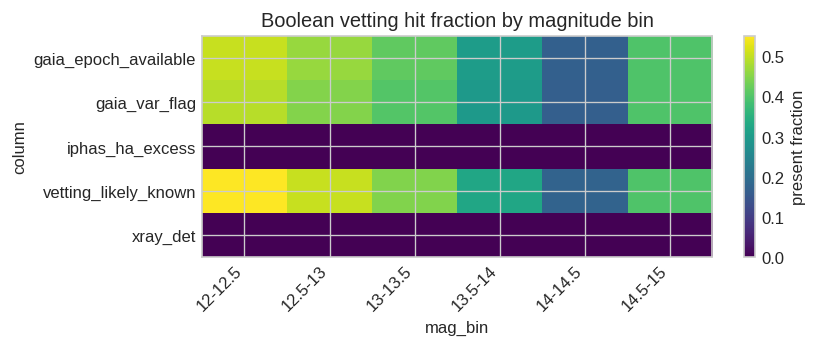

In [19]:
boolean_cols = [c for c in discovered_vetting_cols if INVENTORY_MAP[c]['column_type'] == 'boolean']
plot_boolean_overview(df_vet, boolean_cols)


## Categorical Fields

Top-N categories are shown for categorical vetting outputs such as SIMBAD types or Gaia variable classes.


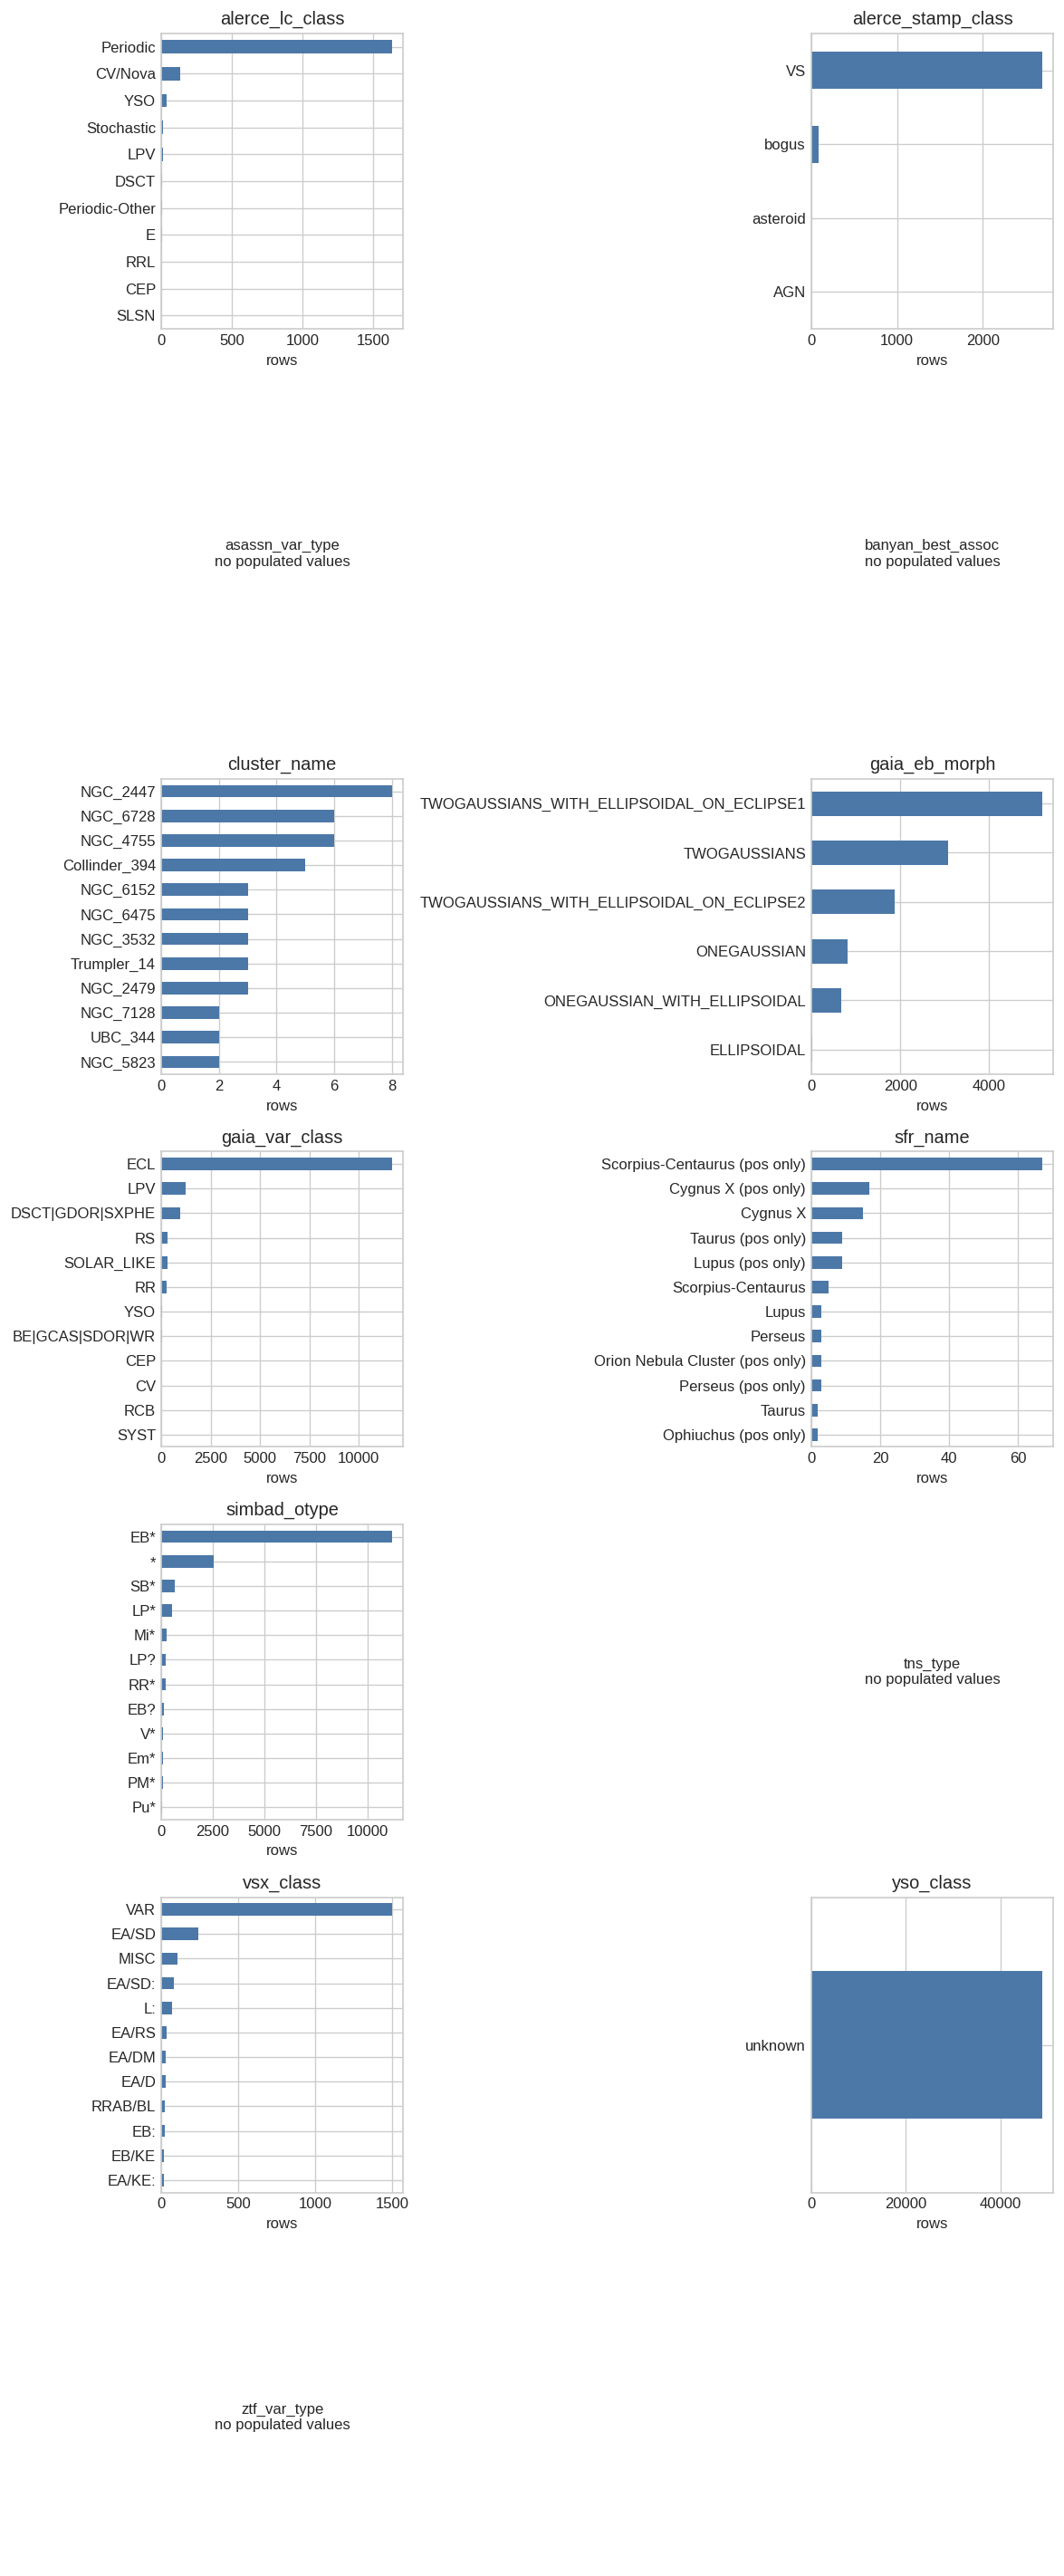

In [20]:
categorical_cols = [c for c in discovered_vetting_cols if INVENTORY_MAP[c]['column_type'] == 'categorical']
plot_categorical_grid(df_vet, categorical_cols)


## Numeric Retrieved Stats

Every numeric vetting field available in the loaded data is plotted below. Long-tailed positive quantities use `log10(...)` automatically.


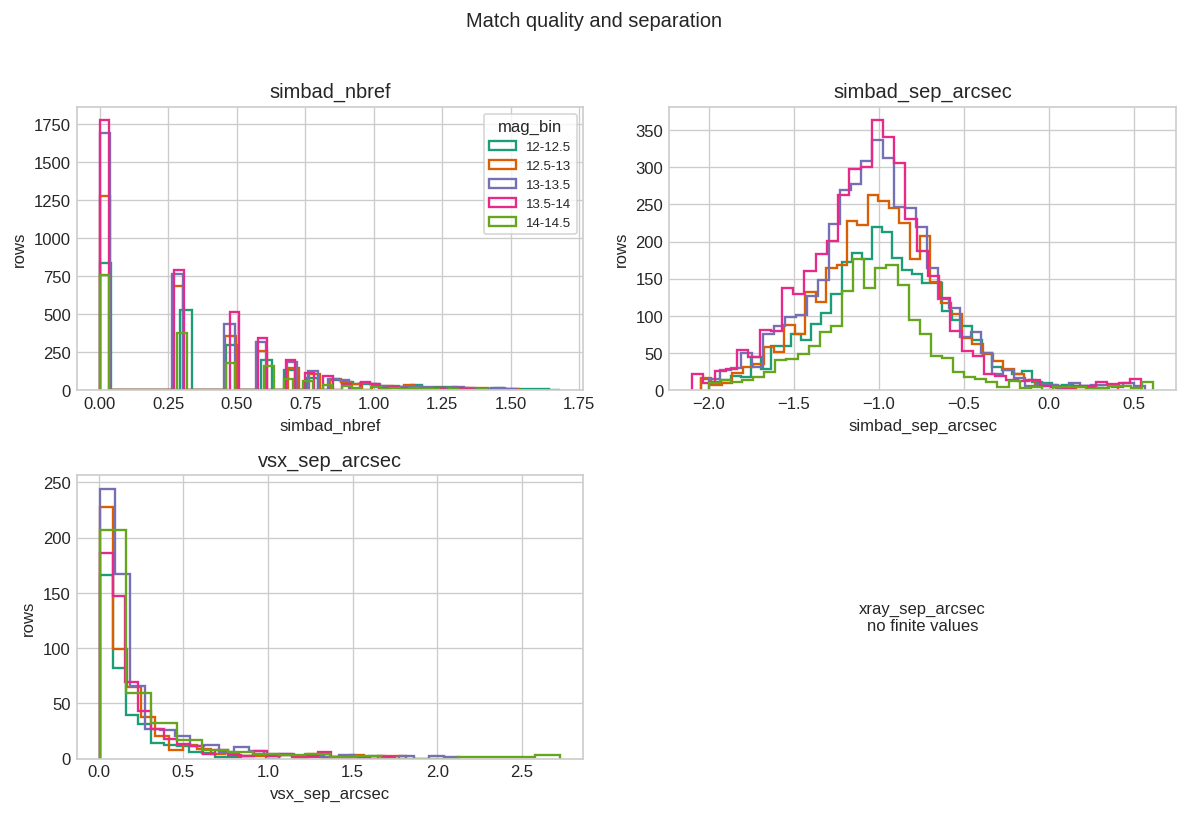

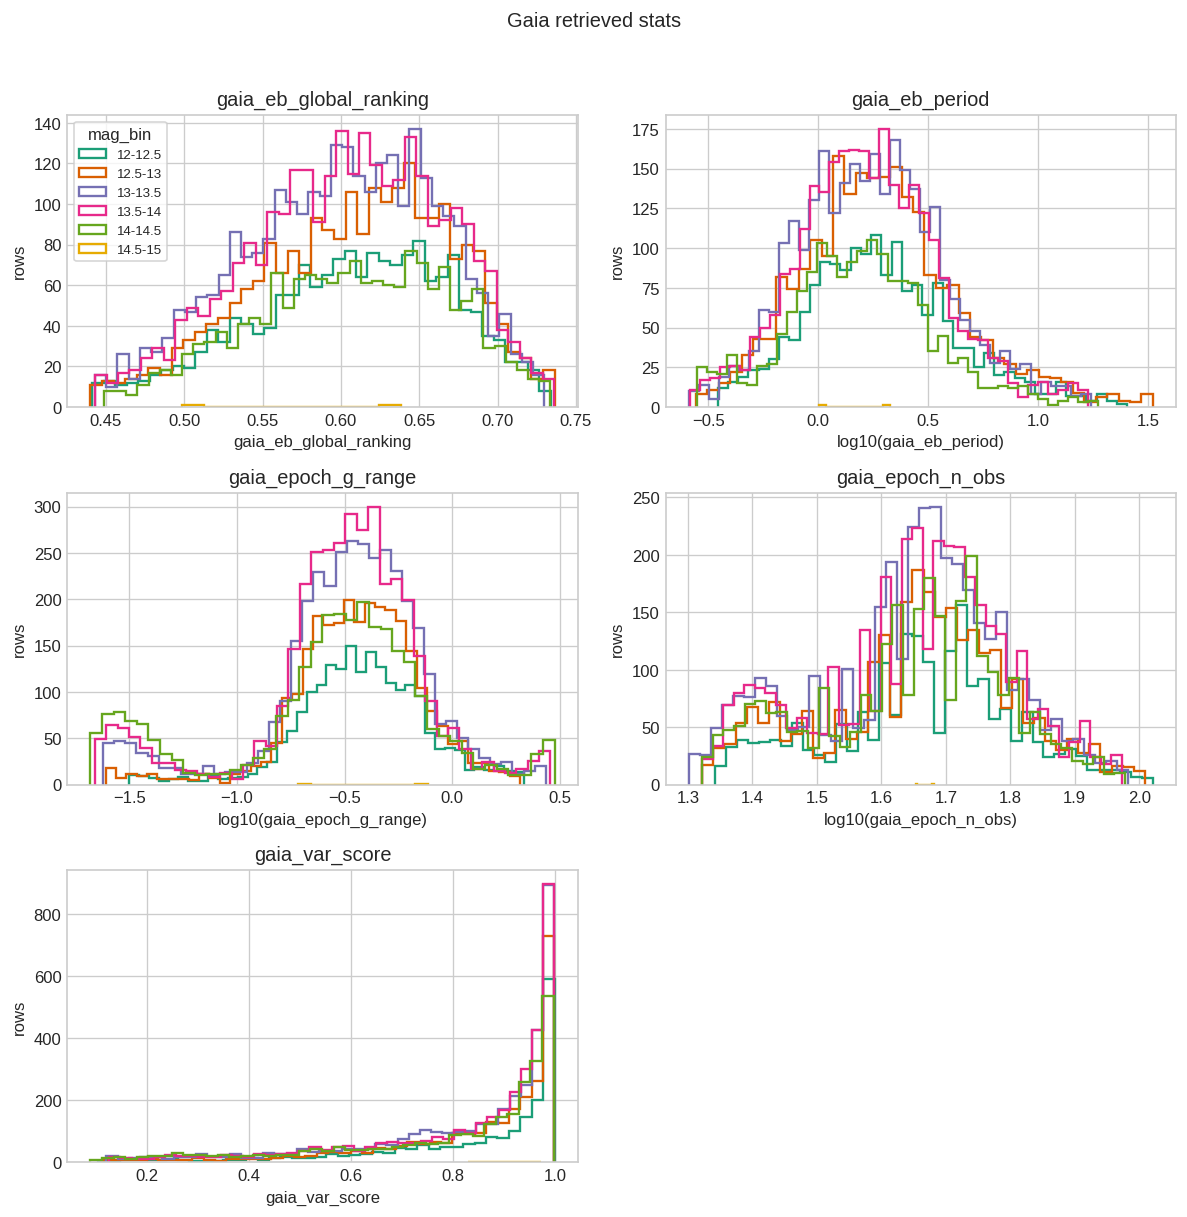

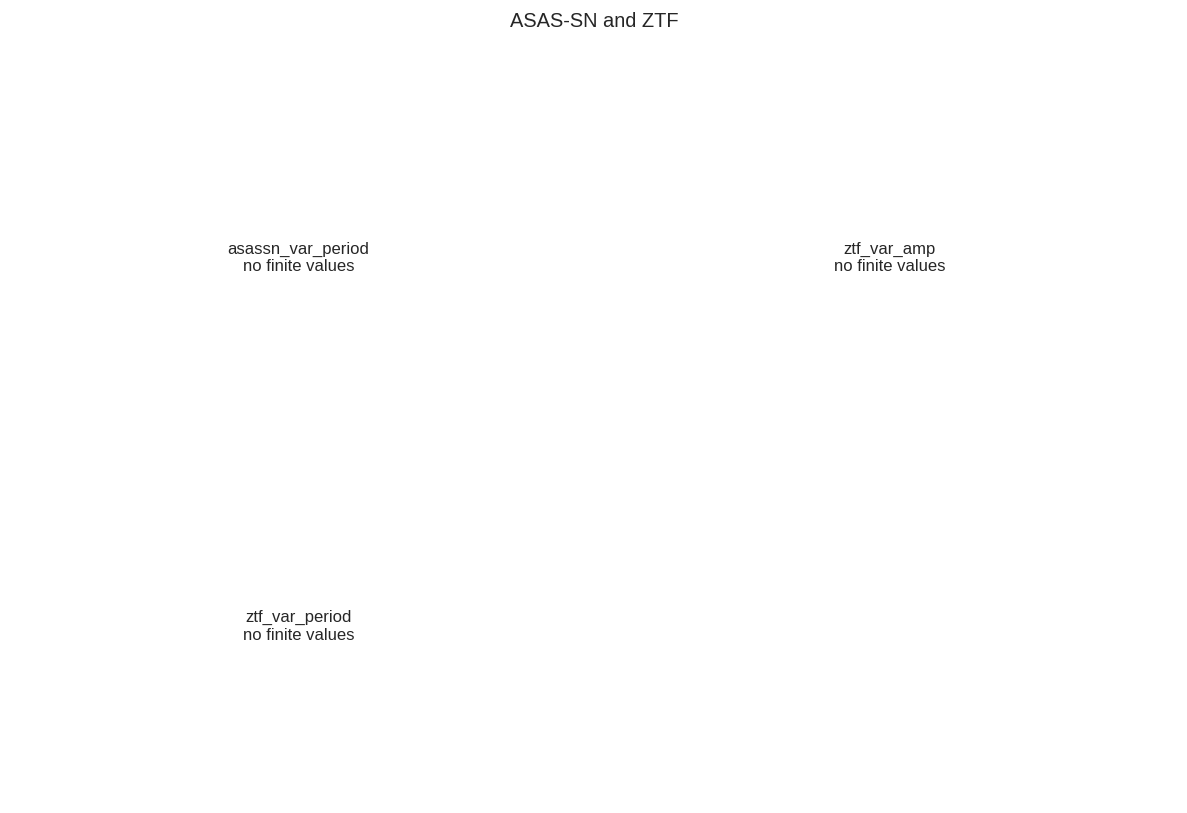

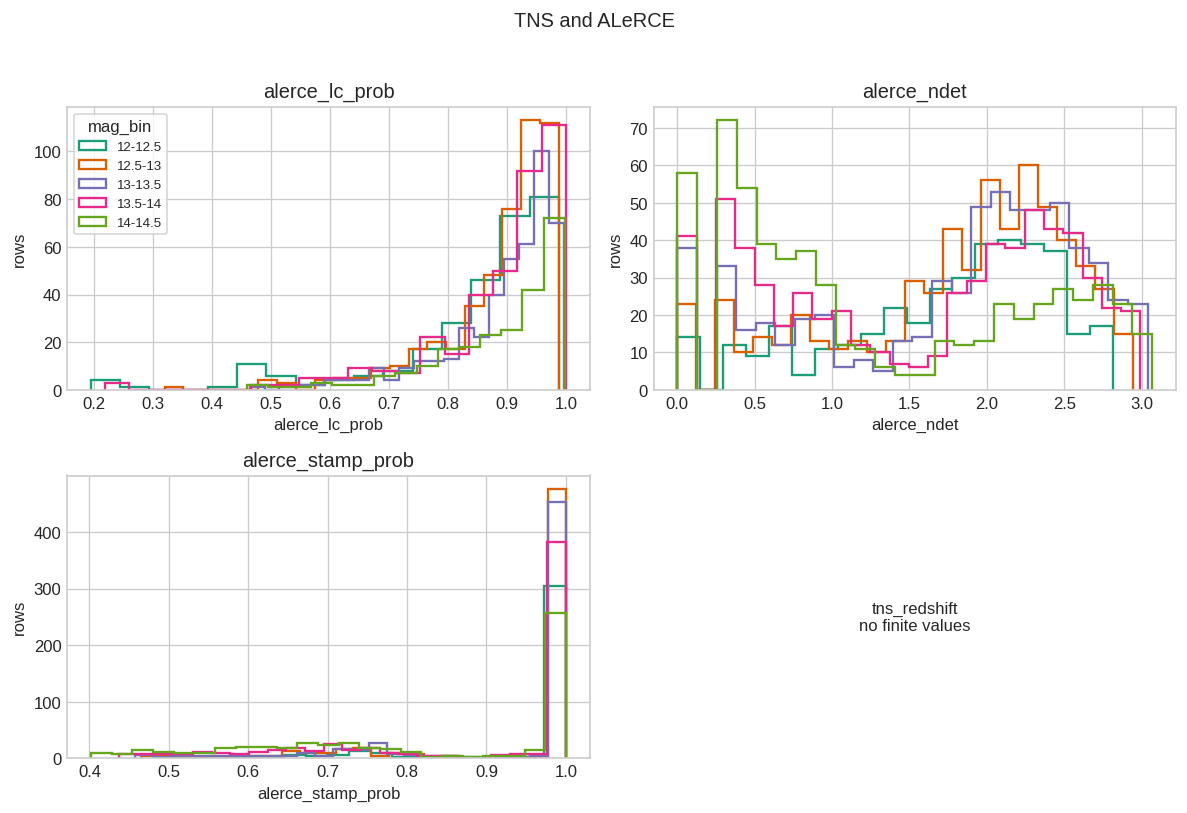

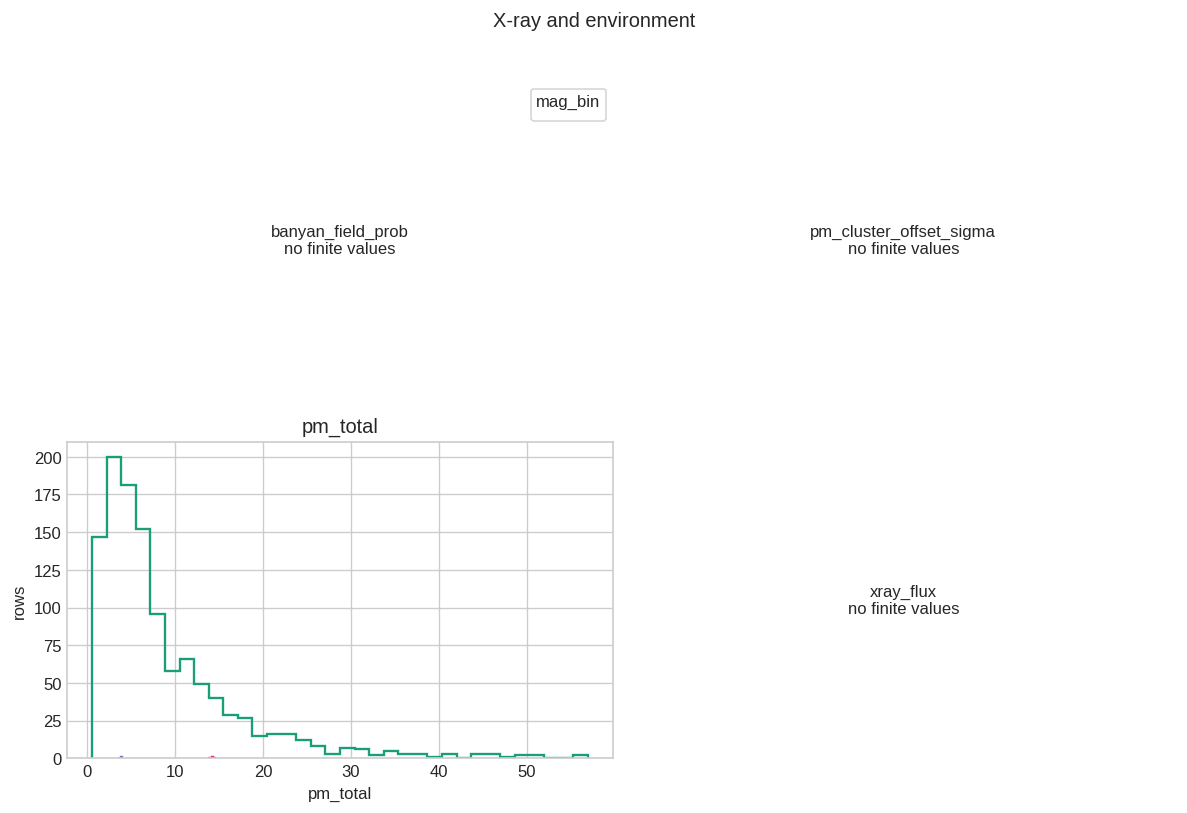

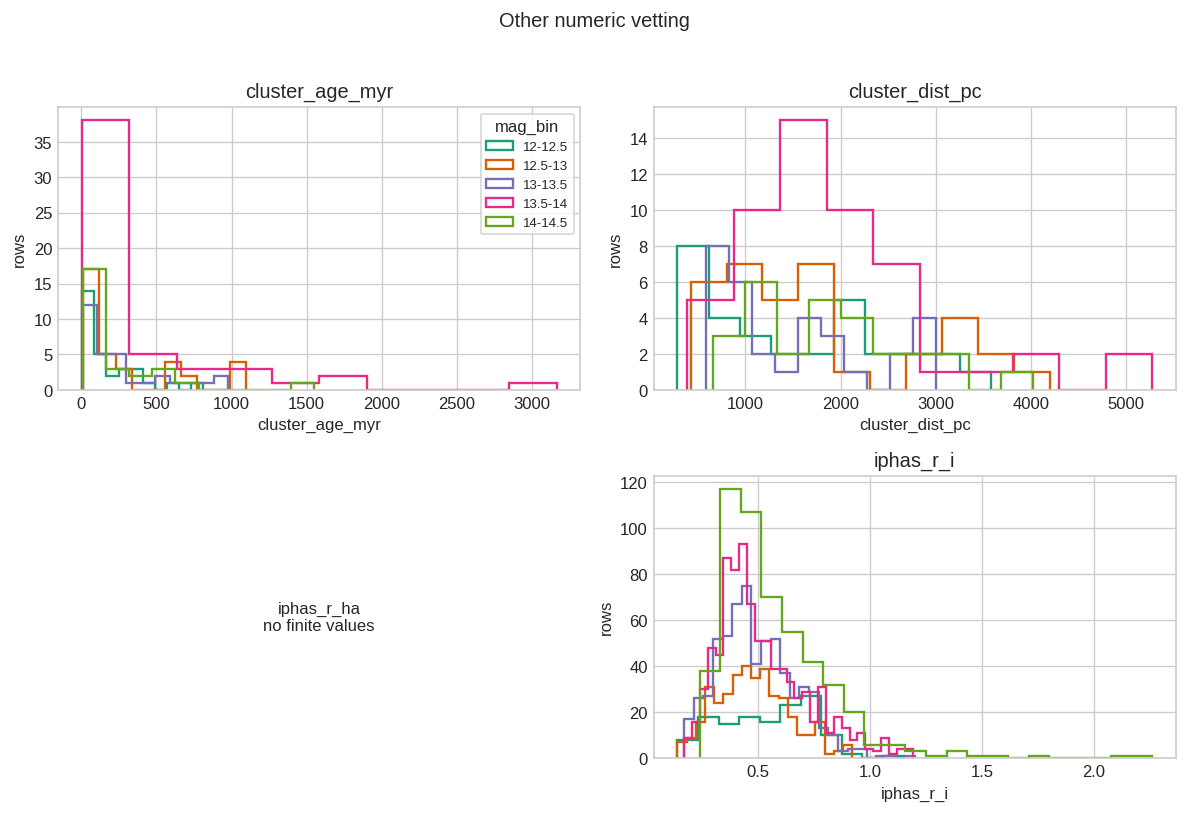

In [21]:
numeric_cols = [c for c in discovered_vetting_cols if INVENTORY_MAP[c]['column_type'] == 'numeric']
for group_name in NUMERIC_GROUP_ORDER:
    group_cols = [c for c in numeric_cols if INVENTORY_MAP[c]['group'] == group_name]
    if group_cols:
        plot_numeric_group(df_vet, group_cols, title=group_name)


## Text-Only Vetting Fields

Free-text identifier fields are still useful as completeness signals even though they are not histogram targets.


In [22]:
text_cols = [c for c in discovered_vetting_cols if INVENTORY_MAP[c]['column_type'] == 'text']
text_completeness = pd.DataFrame(
    [
        {
            'column': col,
            'present_rows': present_count(df_vet[col]),
            'present_fraction': present_count(df_vet[col]) / len(df_vet) if len(df_vet) else np.nan,
        }
        for col in text_cols
    ],
    columns=['column', 'present_rows', 'present_fraction'],
)
if not text_completeness.empty:
    text_completeness = text_completeness.sort_values('present_fraction', ascending=False)
display(text_completeness)


,column,present_rows,present_fraction
2,gaia_id,48831,1.000000
3,simbad_main_id,16606,0.340071
0,alerce_oid,2852,0.058406
1,asassn_var_name,0,0.000000
4,tns_disc_date,0,0.000000
5,tns_name,0,0.000000


## Notes

- Missing vetting columns usually mean the corresponding module was disabled or did not yield matches.
- `atlas_*` fields are often sparse unless ATLAS querying was enabled with a token.
- This notebook only shows fields present in the loaded vetted parquet files, so optional external follow-up columns may not appear.
